## **New Customer Early Value Scoring**

Every model built so far requires calibration-period history, Recency, Frequency, Monetary, computed over weeks or months of behavior. A brand-new customer, someone who just placed their first order, has none of this. This notebook builds a separate model that predicts early customer value using only first-order characteristics, letting the business get an early read on a new customer's likely worth, rather than waiting months to accumulate enough history for our existing models to apply.

For every customer in our full dataset, we identify their very first purchase, and describe it with features available at that exact moment: order value, number of items, number of distinct products, unit price patterns. We then look forward to see how much that customer actually spent over the following months, and train a model to predict that future value from first-order characteristics alone.

Our 6-month and 12-month CLV models use calibration/holdout splits based on a fixed cutoff date, every customer's features are computed as of the same point in time. This notebook instead anchors each customer's features to their own individual first-purchase date, which differs customer to customer, this is a "cohort-relative" rather than "calendar-relative" approach, a genuinely different framing worth understanding clearly before building it.

#### Planned Approach

1. Identify each customer's first purchase, and compute first-order features (order value, item count, distinct products, average unit price)
2. Define a forward-looking value window (a fixed number of days after first purchase, we'll decide how many based on data coverage)
3. Compute the target: total spend in that window, excluding the first order itself
4. Check data availability, since customers whose first purchase happened late in the dataset won't have a full forward window to measure
5. Build and evaluate a regression model, comparing against a naive "assume average" baseline
6. Save the model for the app's "estimate a new customer's value" feature

### Identify First Purchases and Build First-Order Features

For every customer, we identify their first invoice and compute features describing that single order: total value, item count, distinct products, and average unit price. These are the only signals available about a customer at the moment of their first purchase.

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("../src")
from config import CLEAN_DATA_PATH

df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])
df['Revenue'] = df['Quantity'] * df['Price']

# Identify each customer's first invoice date
first_purchase_date = df.groupby('Customer ID')['InvoiceDate'].min()

# Identify the specific invoice(s) on that first date (a customer might place multiple
# invoices on their very first day, we treat all of them as part of the "first purchase")
df_with_first_date = df.merge(first_purchase_date.rename('First_Purchase_Date'), on='Customer ID')
first_order_transactions = df_with_first_date[
    df_with_first_date['InvoiceDate'].dt.date == df_with_first_date['First_Purchase_Date'].dt.date
]

first_order_features = first_order_transactions.groupby('Customer ID').agg(
    First_Order_Value=('Revenue', 'sum'),
    First_Order_Items=('Quantity', 'sum'),
    First_Order_Distinct_Products=('StockCode', 'nunique'),
    First_Order_Avg_Price=('Price', 'mean'),
    First_Purchase_Date=('InvoiceDate', 'min')
)

print("Number of customers with first-order features:", len(first_order_features))
first_order_features.describe()

Number of customers with first-order features: 5861


,First_Order_Value,First_Order_Items,First_Order_Distinct_Products,First_Order_Avg_Price,First_Purchase_Date
count,5861.000000,5861.000000,5861.000000,5861.000000,5861
mean,430.781424,271.177785,24.681795,3.731790,2010-08-22 12:07:16.901552
min,1.300000,1.000000,1.000000,0.151333,2009-12-01 07:45:00
25%,169.550000,84.000000,10.000000,2.077000,2010-02-09 13:56:00
50%,297.680000,158.000000,19.000000,2.852222,2010-06-28 11:11:00
75%,453.100000,287.000000,32.000000,3.823684,2011-01-31 13:39:00
max,39916.500000,87167.000000,259.000000,434.650000,2011-12-09 12:16:00
std,987.000311,1247.787463,23.503284,9.639569,NaN


### Define the Forward-Looking Value Window and Check Data Availability

We need a fixed window after each customer's first purchase to measure their subsequent value, but customers whose first purchase happened late in the dataset won't have a full window available before the data ends. We check this directly before choosing a window length.

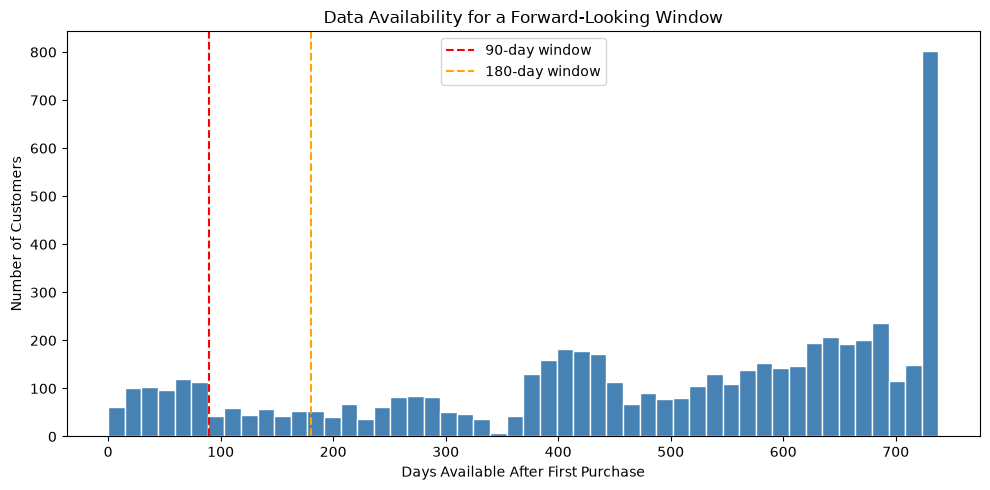

Customers with at least 30 days available: 5700 (97.3%)
Customers with at least 60 days available: 5501 (93.9%)
Customers with at least 90 days available: 5265 (89.8%)
Customers with at least 180 days available: 4962 (84.7%)
Customers with at least 365 days available: 4294 (73.3%)


In [2]:
dataset_end_date = df['InvoiceDate'].max()

# For each customer, how many days of "runway" exist between their first purchase and the dataset's end
first_order_features['Days_Available'] = (dataset_end_date - first_order_features['First_Purchase_Date']).dt.days

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(first_order_features['Days_Available'], bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Days Available After First Purchase')
ax.set_ylabel('Number of Customers')
ax.set_title('Data Availability for a Forward-Looking Window')
ax.axvline(90, color='red', linestyle='--', label='90-day window')
ax.axvline(180, color='orange', linestyle='--', label='180-day window')
ax.legend()
plt.tight_layout()
plt.show()

for window in [30, 60, 90, 180, 365]:
    n_customers = (first_order_features['Days_Available'] >= window).sum()
    print(f"Customers with at least {window} days available: {n_customers} ({n_customers/len(first_order_features)*100:.1f}%)")

#### Choosing the Window Length

Data availability declines gradually as the window lengthens: 89.8% of customers retained at 90 days, 84.7% at 180 days, 73.3% at 365 days. Given this project's purpose, giving a business an early read on a new customer, a shorter window is also more practically useful, a business wants to know a new customer's likely value soon after their first purchase, not a year later. We select a 90-day window, balancing strong data retention (89.8%) with a genuinely early, actionable prediction horizon.

In [3]:
window_days = 90

eligible_customers = first_order_features[first_order_features['Days_Available'] >= window_days].index
print(f"Customers eligible for {window_days}-day window modeling: {len(eligible_customers)}")

Customers eligible for 90-day window modeling: 5265


### Compute the Forward-Looking Target

For each eligible customer, we compute total spend in the 90 days following their first purchase date, excluding the first order itself, since we want to predict *additional* value beyond what's already known at the point of first purchase.

In [4]:
# Merge first purchase date onto the full transaction data for eligible customers
df_eligible = df[df['Customer ID'].isin(eligible_customers)].merge(
    first_order_features[['First_Purchase_Date']], on='Customer ID'
)

# Define each customer's window end date
df_eligible['Window_End'] = df_eligible['First_Purchase_Date'] + pd.Timedelta(days=window_days)

# Target: revenue from transactions strictly after the first purchase date, within the window
future_transactions = df_eligible[
    (df_eligible['InvoiceDate'] > df_eligible['First_Purchase_Date']) &
    (df_eligible['InvoiceDate'] <= df_eligible['Window_End'])
]

future_value = future_transactions.groupby('Customer ID')['Revenue'].sum()

# Reindex to all eligible customers, filling non-returning customers with 0
target = future_value.reindex(eligible_customers, fill_value=0)
target.name = 'Future_90Day_Value'

print("Target shape:", target.shape)
print(f"\nCustomers with zero future value (no return purchase in 90 days): {(target == 0).sum()} ({(target == 0).mean()*100:.1f}%)")
target.describe()

Target shape: (5265,)

Customers with zero future value (no return purchase in 90 days): 2809 (53.4%)


count      5265.000000
mean        427.676286
std        2448.361468
min           0.000000
25%           0.000000
50%           0.000000
75%         356.030000
max      101294.200000
Name: Future_90Day_Value, dtype: float64

53.4% of customers show zero spend in the 90 days following their first purchase, the highest non-return rate among all three windows examined in this project (48% at 6 months, 35.9% at 12 months, 53.4% at 90 days), consistent with the shorter window giving customers less time to return. The 25th and 50th percentiles both sit at exactly £0, confirming heavy zero-inflation, with a max of £101,294.20, indicating at least one customer made an enormous follow-up purchase shortly after their first order. Given the two-stage architecture's proven success at both other time horizons in this project, we proceed directly to that approach here, rather than re-demonstrating the naive baseline's known flaw.

### Quick Naive Baseline Check

We confirm the same negative-prediction pattern found at both other time horizons replicates here too, with a compressed, single-step check rather than the full diagnostic treatment given the first time this was demonstrated, since the underlying mechanism is already well established.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_first_order = first_order_features.loc[eligible_customers, [
    'First_Order_Value', 'First_Order_Items', 'First_Order_Distinct_Products', 'First_Order_Avg_Price'
]]
y_first_order = target

X_train_fo, X_test_fo, y_train_fo, y_test_fo = train_test_split(
    X_first_order, y_first_order, test_size=0.2, random_state=42
)

naive_model = LinearRegression()
naive_model.fit(X_train_fo, y_train_fo)
y_pred_naive_fo = naive_model.predict(X_test_fo)

mae_naive_fo = mean_absolute_error(y_test_fo, y_pred_naive_fo)
r2_naive_fo = r2_score(y_test_fo, y_pred_naive_fo)
neg_naive_fo = (y_pred_naive_fo < 0).sum()

print(f"MAE: £{mae_naive_fo:.2f}")
print(f"R²: {r2_naive_fo:.3f}")
print(f"Negative predictions: {neg_naive_fo} out of {len(y_pred_naive_fo)} ({neg_naive_fo/len(y_pred_naive_fo)*100:.1f}%)")

MAE: £494.45
R²: 0.050
Negative predictions: 0 out of 1053 (0.0%)


Unlike the 6-month and 12-month naive baselines, this model produces zero negative predictions, but at the cost of very weak explanatory power (R-squared 0.050, essentially no better than predicting the average for every customer). This is a different failure mode than seen previously: with only four first-order features available (order value, item count, distinct products, average price), a much narrower signal than the full RFM feature set used elsewhere in this project, the model's coefficients remain small, keeping predictions clustered near the target's average rather than swinging far enough in either direction to go negative. This model is safe but uninformative, rather than informative but occasionally invalid, a genuinely different, and arguably more concerning, problem: a model this weak provides little real value for early customer scoring, regardless of its prediction validity. This motivates trying the two-stage approach not just for its safety guarantee, but specifically to see whether separating the "will they return" and "how much" questions can extract more genuine signal from these limited first-order features.

### Two-Stage Model

We build a two-stage model using only first-order features: Stage 1 predicts whether a customer will make any purchase within 90 days, Stage 2 predicts how much, trained only on customers who did return. This tests whether separating these two questions extracts more genuine signal than the naive baseline achieved.

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

y_returned_full = (y_first_order > 0).astype(int)

X_train_fo, X_test_fo, y_train_fo, y_test_fo, y_returned_train_fo, y_returned_test_fo = train_test_split(
    X_first_order, y_first_order, y_returned_full, test_size=0.2, random_state=42
)

# Stage 1: will they return within 90 days?
stage1_new_cust = GradientBoostingClassifier(random_state=42, learning_rate=0.1, max_depth=2, n_estimators=50)
stage1_new_cust.fit(X_train_fo, y_returned_train_fo)

# Stage 2: how much, given they return? Trained only on customers who did return
train_returners_mask = y_returned_train_fo == 1
X_train_returners = X_train_fo[train_returners_mask]
y_train_returners = y_train_fo[train_returners_mask]

stage2_new_cust = LinearRegression()
stage2_new_cust.fit(X_train_returners, y_train_returners)

print(f"Training on {len(X_train_returners)} returning customers (out of {len(X_train_fo)} total training customers)")

Training on 1965 returning customers (out of 4212 total training customers)


#### Evaluate the Two-Stage Model

In [7]:
p_return = stage1_new_cust.predict_proba(X_test_fo)[:, 1]
predicted_amount_if_return = np.clip(stage2_new_cust.predict(X_test_fo), 0, None)

# Test both combination approaches, same as done in the 6-month and 12-month notebooks
final_expected_value = p_return * predicted_amount_if_return

thresholds_to_test = np.arange(0.1, 0.95, 0.05)
threshold_results = []
for thresh in thresholds_to_test:
    pred_binary = (p_return >= thresh).astype(int)
    final_hard = np.where(pred_binary == 1, predicted_amount_if_return, 0)
    mae_t = mean_absolute_error(y_test_fo, final_hard)
    threshold_results.append({"Threshold": thresh, "MAE": mae_t})

threshold_df = pd.DataFrame(threshold_results)
best_threshold_row = threshold_df.loc[threshold_df["MAE"].idxmin()]

mae_ev = mean_absolute_error(y_test_fo, final_expected_value)
r2_ev = r2_score(y_test_fo, final_expected_value)

print("Expected Value Approach")
print(f"MAE: £{mae_ev:.2f}, R²: {r2_ev:.3f}")

print(f"Best Hard Cutoff Threshold")
print(f"Threshold: {best_threshold_row['Threshold']:.2f}, MAE: £{best_threshold_row['MAE']:.2f}")

best_thresh = best_threshold_row['Threshold']
final_pred_binary = (p_return >= best_thresh).astype(int)
final_hard_best = np.where(final_pred_binary == 1, predicted_amount_if_return, 0)
r2_hard_best = r2_score(y_test_fo, final_hard_best)
print(f"R² at best threshold: {r2_hard_best:.3f}")

print(f"Comparison to Naive Baseline")
print(f"Naive: MAE £{mae_naive_fo:.2f}, R² {r2_naive_fo:.3f}")

Expected Value Approach
MAE: £496.15, R²: 0.050
Best Hard Cutoff Threshold
Threshold: 0.65, MAE: £419.20
R² at best threshold: 0.046
Comparison to Naive Baseline
Naive: MAE £494.45, R² 0.050


Unlike the 6-month and 12-month notebooks, the two-stage architecture provides no meaningful improvement over the naive baseline (R-squared 0.046-0.050 versus 0.050, essentially unchanged). This differs from those results because two-stage modeling's benefits there came from two sources: guaranteeing valid, non-negative predictions, and separating two genuinely learnable signals a single model conflated. Here, the naive baseline already produced zero negative predictions, so the safety benefit is moot, and the accuracy benefit fails to materialize because the underlying first-order features (order value, item count, distinct products, average price) simply carry very little genuine predictive signal about a customer's future value. Restructuring the model architecture cannot extract information that is not present in the input features to begin with.

This is a genuine, worthwhile finding rather than a failed experiment: it demonstrates that early customer value is, at least from these basic first-purchase statistics alone, close to unpredictable. A first-time buyer's initial order size and composition tell us very little about whether or how much they'll buy again, this itself is useful business knowledge, suggesting early retention efforts (welcome emails, second-purchase incentives) may be more valuable applied broadly across new customers rather than narrowly targeted at a subset predicted to be "high value," since that prediction is not currently reliable.

### Decision: We don't Deploy this Model

Given the weak, unimproved predictive power (R-squared approximately 0.05 across every approach tried), we do not save or deploy a new-customer scoring model. Shipping a model this weak would risk presenting false precision to a business user, a predicted CLV figure implies confidence the underlying model does not actually have. This is a deliberate, evidence-based decision to not build a feature, rather than defaulting to shipping whatever was built regardless of quality.

### Summary

This notebook investigated whether a customer's early value could be predicted from first-order characteristics alone (order value, item count, distinct products, average price), rather than the accumulated behavioral history our other models require.

**Key findings:**

- **5,861 customers had identifiable first-order features**; 5,265 (89.8%) had sufficient forward-looking data within a chosen 90-day window, selected to balance data retention against giving a business a genuinely early read on new customers.
- **53.4% of customers made no return purchase within 90 days**, the highest zero-inflation rate among the three time horizons examined across this project (48% at 6 months, 35.9% at 12 months).
- **The naive baseline, unusually, produced zero negative predictions**, but only because its R-squared (0.050) was too weak to produce confident predictions in either direction, a different, and more concerning, failure mode than seen at the other two horizons.
- **The two-stage architecture, successful at both other time horizons, provided no meaningful improvement here** (R-squared 0.046-0.050 across every combination method tested). This is explained by the underlying features themselves carrying very little genuine predictive signal, a model architecture cannot manufacture information the input features do not contain.
- **Decision: no model was deployed from this notebook.** Given the consistently weak explanatory power across every approach tried, shipping a scoring feature here would present false precision to a business user. This is a deliberate, evidence-based decision not to build a feature, rather than defaulting to deployment regardless of quality.

**Business implication:** early customer value, from first-purchase statistics alone, appears close to unpredictable in this dataset. This suggests retention efforts aimed at new customers (welcome offers, second-purchase incentives) are better applied broadly across all new customers, rather than narrowly targeted at a subset predicted to be high-value, since that prediction is not currently reliable. A genuine improvement would likely require richer first-order features not explored here (product category, seasonal timing, geographic signals) or a fundamentally different modeling approach, both reasonable directions for future work rather than something to force into the current scope.

**Output:** None, this notebook concludes with a documented negative result rather than a deployable artifact.